# Shear, WCS and `drawImage` in GalSim / ngmix (metacalibration view)

This notebook demonstrates three tightly-coupled ideas:

1. A GalSim `GSObject` is defined in the **RA/Dec (celestial) coordinate system**. When we
   call `.shear(g1, g2)`, the shear is applied **in that RA/Dec frame** — so a pure `g1 > 0`
   always elongates the object **along the RA axis**, regardless of any detector. (The object
   is "abstract" only in the sense that it has not yet been rendered onto a pixel grid — but
   the frame it lives in is concretely RA/Dec, GalSim's world coordinates `(u, v)`.)

2. A **WCS / local Jacobian** maps RA/Dec `(u, v)` ↔ pixel `(x, y)`. The per-cutout Jacobian
   is the linear map `(dx, dy) -> (du, dv)`; decomposing it gives a *scale*, an intrinsic
   *shear*, a *rotation θ*, and a *flip*, where θ is that exposure's roll relative to the sky.

3. `drawImage(wcs=...)` is the step that *applies* the WCS. Shear is spin-2: under a rotation
   by θ the complex shear transforms as `g -> g · e^{±2iθ}`, so the ellipse's position angle
   simply rotates by θ. A pure RA-frame `g1` therefore lands at a **different pixel angle in
   every exposure**, set by each exposure's θ. A SWarp coadd resamples everything onto a
   common north-up / east-left grid (θ ≈ 0, plus the usual RA parity flip), so there `g1 = 0.5`
   shows up as a clean horizontal stretch — un-rotated — while exp1…expN show it at assorted
   angles.

We simulated Abell 1689 (SuperBIT) with every galaxy sheared by `g1 = 0.5, g2 = 0` in the
RA/Dec frame. We then show that re-shearing one exposure *through its own WCS* adds elongation
along the **same** pixel direction the object already has — exactly the machinery ngmix
metacalibration relies on to apply a consistent physical shear across rotated exposures.

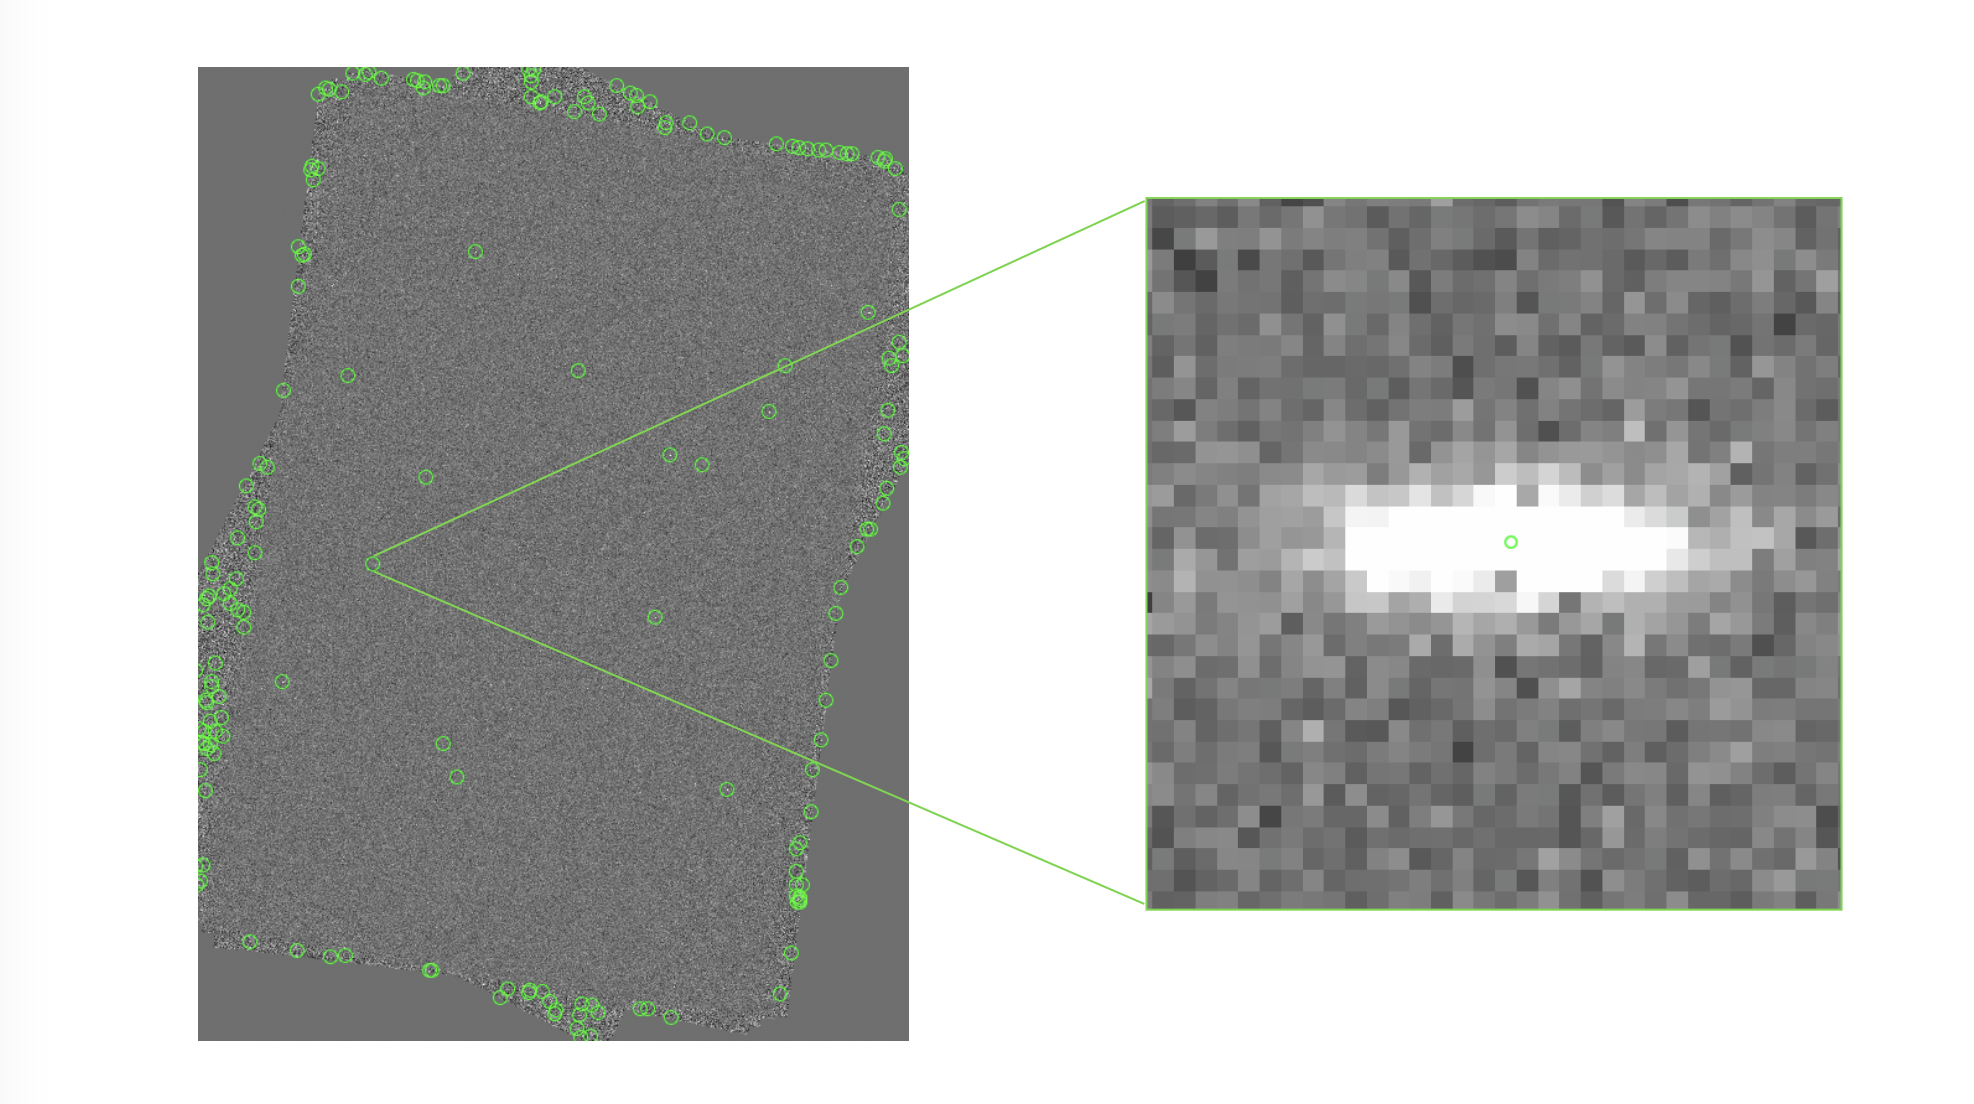

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import galsim
from astropy.io import fits
from astropy.visualization import ZScaleInterval
from ngmix.medsreaders import NGMixMEDS

## Load the MEDS and pick one object

`obj_id = 85` (catalog `id`). MEDS cutout 0 is the **coadd**; the rest are the single-epoch
exposures. ngmix's `get_obslist` returns the **single-epoch** observations (no coadd), so
`obslist[0]` is **exp1**, not the coadd — this is why it carries a non-zero WCS rotation.

In [2]:
meds_file = "/projects/mccleary_group/saha/batch_sims/data/sim_Abell1689/b/out/sim_Abell1689_b_meds.fits"
medsObj = NGMixMEDS(meds_file)

obj_id = 85
wmask = obj_id == medsObj['id']
true_indices = np.where(wmask)[0]
idx = true_indices[0]

obslist = medsObj.get_obslist(idx, 'uberseg')   # single-epoch exposures (coadd excluded)
print(f"catalog id = {obj_id}, MEDS row idx = {idx}, n single-epoch obs = {len(obslist)}")

catalog id = 85, MEDS row idx = 84, n single-epoch obs = 5


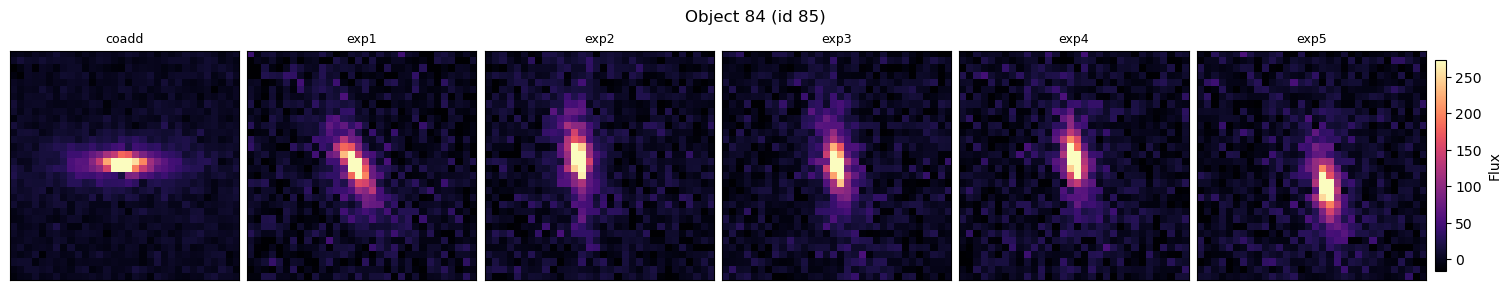

In [3]:
n_stamps   = medsObj[idx]['ncutout']     # includes coadd as index 0
stamp_size = medsObj[idx]['box_size']

cutouts = [medsObj.get_cutout(idx, i) for i in range(n_stamps)]
labels  = ['coadd'] + [f'exp{i}' for i in range(1, n_stamps)]

interval = ZScaleInterval()
vmin, vmax = interval.get_limits(cutouts[0])   # anchor scale to the coadd

fig, axes = plt.subplots(1, n_stamps, figsize=(2.5 * n_stamps, 3), constrained_layout=True)
for ax, cutout, label in zip(axes, cutouts, labels):
    im = ax.imshow(cutout, origin='lower', cmap='magma',
                   vmin=vmin, vmax=5 * vmax, interpolation='nearest')
    ax.set_title(label, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])

fig.colorbar(im, ax=axes[-1], fraction=0.046, pad=0.04, label='Flux')
fig.suptitle(f'Object {idx} (id {obj_id})', y=1.02)
plt.show()

### What the panel shows

Every panel is the **same galaxy with the same physical shear** (`g1 = 0.5, g2 = 0`, world frame).

- **coadd:** north-up/east-left grid → the stretch is horizontal (along the image x-axis ≈ RA).
- **exp1…expN:** each detector had a different roll on the sky, so the *same* world shear
  appears elongated along a *different* pixel direction in each exposure.

The orientation is not a property of the galaxy or of the shear — it's the **WCS rotation**
of each exposure showing up. Let's read those rotation angles directly off the Jacobians.

In [5]:
print(f"{'obs':<8}{'scale [arcsec/pix]':>20}{'rotation θ [deg]':>18}{'flip':>8}")
for i, obs in enumerate(obslist):
    wcs = obs.jacobian.get_galsim_wcs()      # local galsim.JacobianWCS
    scale, shr, theta, flip = wcs.getDecomposition()
    print(f"{'exp'+str(i+1):<8}{scale:>20.4f}{theta/galsim.degrees:>18.2f}{str(flip):>8}")

# getDecomposition() factorises the Jacobian into (scale, intrinsic shear, rotation θ, flip).
# θ is this exposure's roll relative to the sky; `flip` is the usual RA parity flip.
# These angles are exactly what set the orientation you see in exp1…expN above.

obs       scale [arcsec/pix]  rotation θ [deg]    flip
exp1                  0.1409             62.81   False
exp2                  0.1409             82.98   False
exp3                  0.1409             81.30   False
exp4                  0.1408             79.61   False
exp5                  0.1407             78.07   False


## Going back and forth: image → abstract GSObject → image

To prove the shear lives in the world frame and that the WCS is what places it on the pixel
grid, we take **exp1** and:

1. Wrap the pixel array in a `galsim.Image` **with its Jacobian WCS**.
2. Build an `InterpolatedImage` — now it's an abstract `GSObject` defined in the **world** frame.
3. `drawImage(wcs=<same WCS>)` back onto the pixel grid.

Step 0: do this with **no shear** first, as a sanity check that the round-trip is lossless
(up to interpolation). `method='no_pixel'` because the data already contains the pixel
response — we don't want to convolve by the pixel a second time.

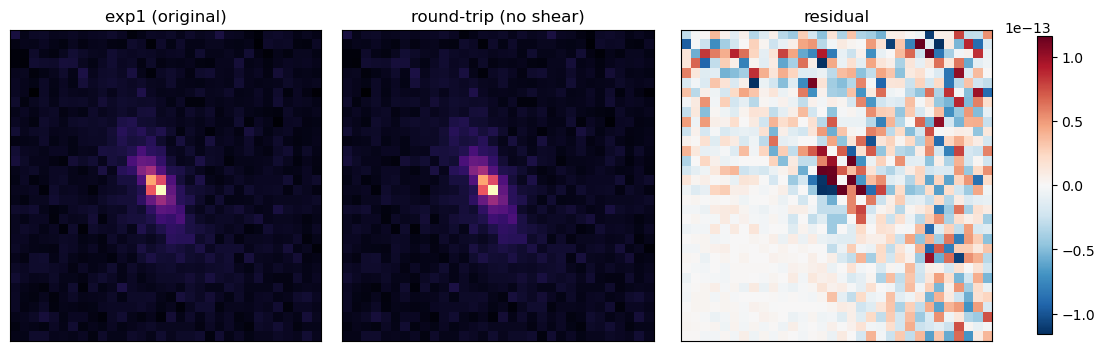

residual / peak flux: 3.337244815590531e-16


In [6]:
obs   = obslist[0]                  # exp1
image = obs.image
wcs   = obs.jacobian.get_galsim_wcs()

gal_im = galsim.Image(np.ascontiguousarray(image), wcs=wcs)
ii     = galsim.InterpolatedImage(gal_im, x_interpolant='lanczos15')

ny, nx = gal_im.array.shape
roundtrip = ii.drawImage(nx=nx, ny=ny, wcs=wcs, method='no_pixel', dtype=np.float64)
resid = roundtrip.array - image

fig, ax = plt.subplots(1, 3, figsize=(11, 3.4), constrained_layout=True)
ax[0].imshow(image,           origin='lower', cmap='magma'); ax[0].set_title('exp1 (original)')
ax[1].imshow(roundtrip.array, origin='lower', cmap='magma'); ax[1].set_title('round-trip (no shear)')
m = np.percentile(np.abs(resid), 99)
im = ax[2].imshow(resid, origin='lower', cmap='RdBu_r', vmin=-m, vmax=m)
ax[2].set_title('residual'); fig.colorbar(im, ax=ax[2], fraction=0.046, pad=0.04)
for a in ax: a.set_xticks([]); a.set_yticks([])
plt.show()

print("residual / peak flux:", np.abs(resid).max() / image.max())

## Add a world-frame shear and redraw through the same WCS

Apply `g1 = 0.2, g2 = 0` to the abstract object **before** drawing. Because this shear is in
the **same RA/Dec frame** as the original `g1 = 0.5` and we draw with the **same** WCS, the
extra elongation lands along the **same pixel direction** the galaxy already has — it just
gets longer along its existing axis (`+g1 through WCS`).

The third panel does the **wrong** thing on purpose: it ignores the rotation, treating the
pixel grid as if it were the RA/Dec frame (a plain `scale`, θ = 0), then applies the identical
`g1 = 0.2`. Now the extra stretch is genuinely horizontal in *pixels* and **misaligned** with
the galaxy — which is what "applying shear in the wrong frame" looks like.

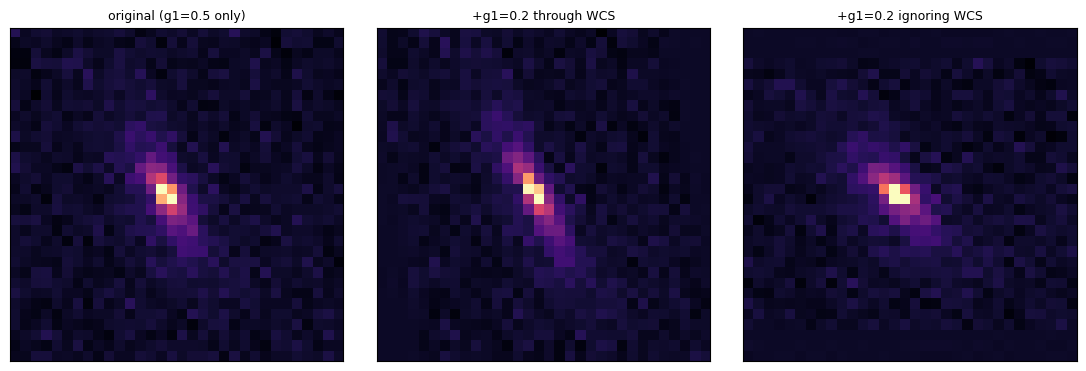

In [15]:
# --- correct: shear in the RA/Dec frame, draw through exp1's WCS ---
sheared = ii.shear(g1=0.2, g2=0.0).drawImage(
    nx=nx, ny=ny, wcs=wcs, method='no_pixel', dtype=np.float64)

# --- WRONG ON PURPOSE: treat the pixel grid as the RA/Dec frame (no rotation) ---
scale = 0.141   # SuperBIT arcsec/pixel; only the *absence of rotation* matters here
gal_im_flat  = galsim.Image(np.ascontiguousarray(image), scale=scale)
ii_flat      = galsim.InterpolatedImage(gal_im_flat, x_interpolant='lanczos15')
sheared_flat = ii_flat.shear(g1=0.2, g2=0.0).drawImage(
    nx=nx, ny=ny, scale=scale, method='no_pixel', dtype=np.float64)

vmin, vmax = ZScaleInterval().get_limits(image)
fig, ax = plt.subplots(1, 3, figsize=(11, 3.6), constrained_layout=True)
for a, t, arr in zip(ax,
                     ['original (g1=0.5 only)', '+g1=0.2 through WCS', '+g1=0.2 ignoring WCS'],
                     [image, sheared.array, sheared_flat.array]):
    a.imshow(arr, origin='lower', cmap='magma', vmin=vmin, vmax=5*vmax)
    a.set_title(t, fontsize=9); a.set_xticks([]); a.set_yticks([])
plt.show()

## Why this matters for metacalibration

ngmix metacal applies its artificial shear (e.g. ±0.01) to the **PSF-deconvolved** galaxy and
reconvolves — and it does the shear **in the world frame using each observation's Jacobian**,
the exact machinery shown above. That's what makes a metacal shear of 0.01 mean the *same
physical shear* on every exposure even though each has a different roll θ. If the shear were
applied in raw pixel coordinates instead, each rotated exposure would receive a *different*
effective shear (the spin-2 `e^{±2iθ}` mixing), the response `R = dⓔ/dγ` would be
inconsistent across epochs, and the recovered shear would be biased.

### Summary
- `GSObject.shear(g1, g2)` acts in the **world** frame; the object is WCS-agnostic until drawn.
- `drawImage(wcs=...)` is where the WCS (rotation + flip + scale) is applied → world → pixels.
- Same world shear + different exposure WCS = different pixel orientation; SWarp coadd ≈ θ=0.
- `Image(array, wcs).InterpolatedImage().shear().drawImage(wcs=same)` round-trips through the
  world frame, so an added `g1` stacks along the galaxy's existing axis — proving the frame.
- This per-observation Jacobian handling is precisely what keeps metacal's response unbiased.